In [34]:
import pandas as pd
from sklearn.preprocessing import normalize, StandardScaler
import os
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools
import numpy as np

In [35]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

In [36]:
from help_functions import build_kmer_dataset,plot_cumulative_variance, apply_pca_transformation,optimize_and_print_kmeans,optimize_and_print_agglomerative, optimize_and_print_gmm, plot_3d, plot_clustering_comparison_3d, run_hantavirus_clustering_pipeline, analyze_clustering_results,extract_kmer_summary

# Učitavanje podataka

In [37]:
complete_sequences_df = pd.read_csv('../data/processed_sequences/final/complete_sequences.csv')

In [38]:
all_sequences_df = pd.read_csv('../data/processed_sequences/final/all_sequences.csv')

In [39]:
all_4_mers = build_kmer_dataset(all_sequences_df,4,'all_4_mers.csv')

In [40]:
complete_4_mers = build_kmer_dataset(complete_sequences_df,4,'complete_4_mers.csv')

## Kumulativna objašnjena varijansa (PCA za 4-mere)

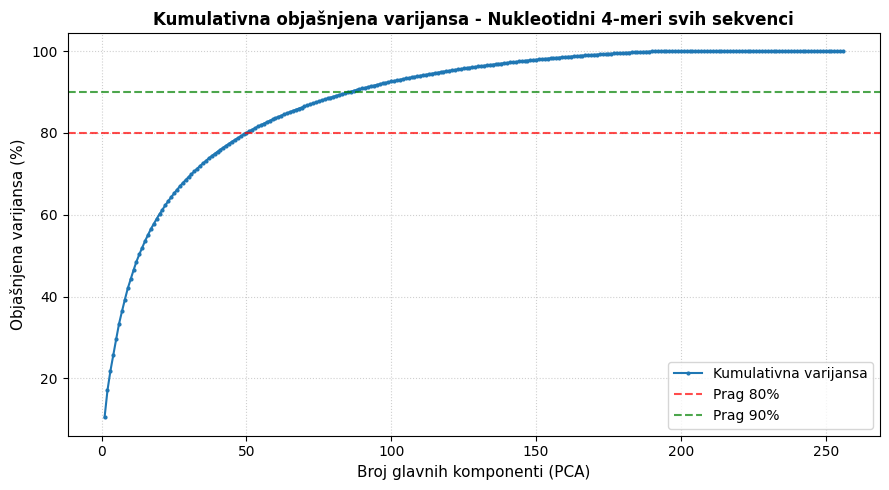

[Nukleotidni 4-meri svih sekvenci] Broj komponenti za 80% varijanse: 50
[Nukleotidni 4-meri svih sekvenci] Broj komponenti za 90% varijanse: 86


In [41]:
plot_cumulative_variance(all_4_mers,'Nukleotidni 4-meri svih sekvenci')

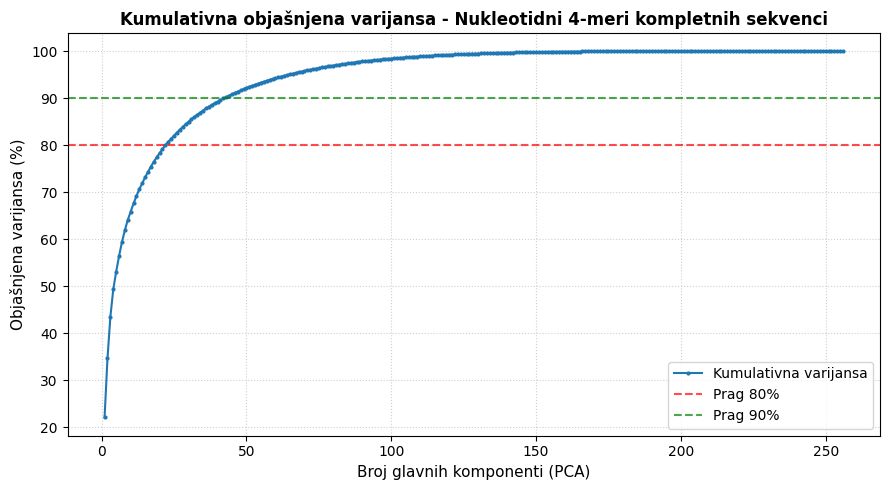

[Nukleotidni 4-meri kompletnih sekvenci] Broj komponenti za 80% varijanse: 23
[Nukleotidni 4-meri kompletnih sekvenci] Broj komponenti za 90% varijanse: 43


In [42]:
plot_cumulative_variance(complete_4_mers,'Nukleotidni 4-meri kompletnih sekvenci')

Analiza redukcije dimenzionalnosti u proširenom prostoru od 256 obeležja ($4^4$) potvrđuju obrazac primećen kod 3-mera:

* **Skup svih sekvenci:**
  * Za dostizanje praga od 80% varijanse potrebno je **50 glavnih komponenti** (86 za 90%).
  * Znatno sporiji rast krive je posledica su prisustva kratkih parcijalnih sekvenci, koji unose šum u profile 4-mera i zahtevaju više od duplo većeg broja dimenzija u poređenju sa kompletnim sekvencama.

* **Skup kompletnih sekvenci:**
  * Prag od 80% varijanse dostiže se sa **23 glavne komponente** (43 za 90%), uz dominantan udeo prvih nekoliko komponenti.

#  Analiza 4-mera kompletnih nukleotida

1. Pokretanje PCA redukcije dimenzionalnosti...
2. Izvršavanje K-Means klasterovanja...
=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 8
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.4171
Davies-Bouldin Index: 1.0587
****************************************
3. Izvršavanje Agglomerative klasterovanja...
=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 8
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silhouette Score: 0.4362
Davies-Bouldin Index: 1.1588
****************************************
4. Izvršavanje GMM klasterovanja...
=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 8
Tip kovarijanse: full
----------------------------------------
Silhouette Score: 0.4171
Davies-Bouldin Index: 1.0587
5. Generisanje uporednog 3D prikaza...


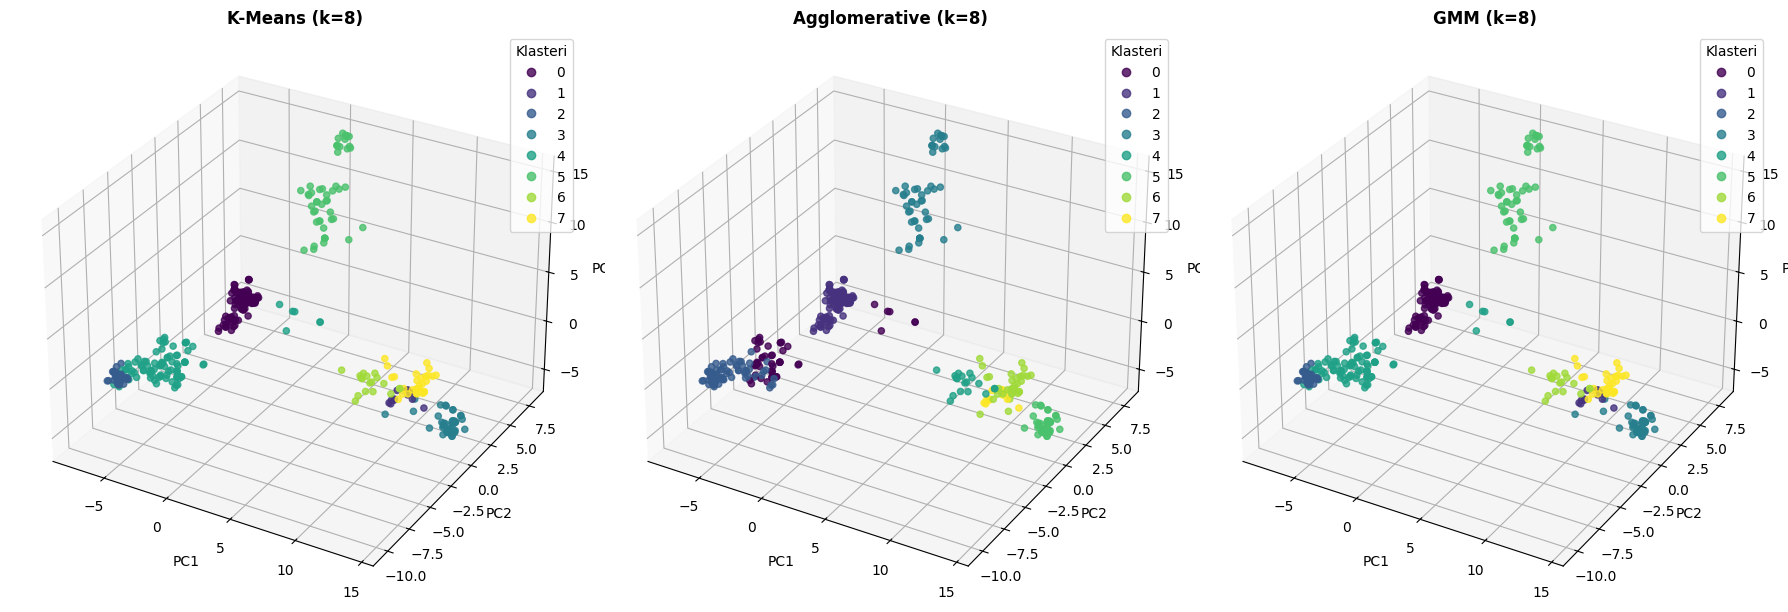

In [43]:
res_complete = run_hantavirus_clustering_pipeline(complete_4_mers, n_components=0.8, plot=True)

### Poređenje rezultata klasterovanja (4-meri kompletnih sekvenci, N = 427)

**Saglasnost algoritama $k = 8$:** Sva tri primenjena algoritma (K-Means, Aglomerativni i GMM) imaju 8 klastera u 23-dimenzionalnom PCA prostoru.

**Metrike:** Aglomerativni model (Ward) postiže najbolju separaciju (Silueta = 0.4362, DB = 1.1588), dok **K-Means** i **GMM** ostvaruju iste rezultate (Silueta = 0.4171, DB = 1.0587).
    
**Poređenje sa 3-merima:** Prelazak sa 3-mera na 4-mere povećao je broj klastera sa $k = 7$ ($k = 4$ kod GMM-a) na $k = 8$. Došlo je do pada silueta koeficijenta sa 0.56 na 0.43 što je očekivano usled veće dimenzionalnosti.

In [44]:
kmeans_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['kmeans'], 
    data= complete_4_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="K-Means"
)

agg_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['agglomerative'], 
    data= complete_4_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="Agglomerative"
)

gmm_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['gmm'], 
    data= complete_4_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="GMM"
)


========================= ANALIZA ZA: K-MEANS =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,130,0,0
1,0,0,12
2,0,44,0
3,0,0,47
4,0,85,6
5,0,0,53
6,0,0,18
7,0,0,32



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,7,86,31,6
1,0,12,0,0
2,0,44,0,0
3,0,47,0,0
4,12,28,39,12
5,0,0,53,0
6,18,0,0,0
7,0,32,0,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=130, pretežno L segment) -> Orthohantavirus hantanense: 86 (66.2%), Orthohantavirus puumalaense: 31 (23.8%), Orthohantavirus dobravaense: 7 (5.4%)
  Klaster 1 (N=12, pretežno S segment) -> Orthohantavirus hantanense: 12 (100.0%)
  Klaster 2 (N=44, pretežno M segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 3 (N=47, pretežno S segment) -> Orthohantavirus hantanense: 47 (100.0%)
  Klaster 4 (N=91, pretežno M segment) -> Orthohantavirus puumalaense: 39 (42.9%), Orthohantavirus hantanense: 28 (30.8%), Orthohantavirus dobravaense: 12 (13.2%)
  Klaster 5 (N=53, pretežno S segment) -> Orthohantavirus puumalaense: 53 (100.0%)
  Klaster 6 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 7 (N=32, pretežno S segment) -> Orthohantavirus hantanense: 32 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> TAGA (Z=1.37), TTAG (Z=1.27), ATGA (Z=1.13)
  Klaster 1 -> CGGC (Z=3.15), TG

...


--- Dominantne vrste po klasterima ---
  Klaster 0 (N=51, pretežno M segment) -> Orthohantavirus puumalaense: 39 (76.5%), Orthohantavirus sinnombreense: 12 (23.5%)
  Klaster 1 (N=130, pretežno L segment) -> Orthohantavirus hantanense: 86 (66.2%), Orthohantavirus puumalaense: 31 (23.8%), Orthohantavirus dobravaense: 7 (5.4%)
  Klaster 2 (N=84, pretežno M segment) -> Orthohantavirus hantanense: 72 (85.7%), Orthohantavirus dobravaense: 12 (14.3%)
  Klaster 3 (N=53, pretežno S segment) -> Orthohantavirus puumalaense: 53 (100.0%)
  Klaster 4 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 5 (N=44, pretežno S segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 6 (N=35, pretežno S segment) -> Orthohantavirus hantanense: 35 (100.0%)
  Klaster 7 (N=12, pretežno S segment) -> Orthohantavirus hantanense: 12 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> TTGT (Z=1.44), TTTG (Z=1.21), TGTA (Z=1.18)
  Klaster 1 -> TAGA (Z=1.37), 

Segment,L,M,S
Cluster,,,
0,130,0,0
1,0,0,12
2,0,44,0
3,0,0,47
4,0,85,6
5,0,0,53
6,0,0,18
7,0,0,32



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,7,86,31,6
1,0,12,0,0
2,0,44,0,0
3,0,47,0,0
4,12,28,39,12
5,0,0,53,0
6,18,0,0,0
7,0,32,0,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=130, pretežno L segment) -> Orthohantavirus hantanense: 86 (66.2%), Orthohantavirus puumalaense: 31 (23.8%), Orthohantavirus dobravaense: 7 (5.4%)
  Klaster 1 (N=12, pretežno S segment) -> Orthohantavirus hantanense: 12 (100.0%)
  Klaster 2 (N=44, pretežno M segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 3 (N=47, pretežno S segment) -> Orthohantavirus hantanense: 47 (100.0%)
  Klaster 4 (N=91, pretežno M segment) -> Orthohantavirus puumalaense: 39 (42.9%), Orthohantavirus hantanense: 28 (30.8%), Orthohantavirus dobravaense: 12 (13.2%)
  Klaster 5 (N=53, pretežno S segment) -> Orthohantavirus puumalaense: 53 (100.0%)
  Klaster 6 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 7 (N=32, pretežno S segment) -> Orthohantavirus hantanense: 32 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> TAGA (Z=1.37), TTAG (Z=1.27), ATGA (Z=1.13)
  Klaster 1 -> CGGC (Z=3.15), TG

### Interpretacija klastera (4-meri kompletnih sekvenci, N = 427)

Na osnovu unakrsnih tabela primećuje se da su K-Means i GMM dobili identične klastere.

Analiza po segmentima: L segmenti se kao i u slučaju kompletnih 3-mera u sva tri algoritma grupišu u jedan čist klaster, ali M segmenti se sada dele u 2 skoro čista klastera.

Analiza po vrstama: S segmenti se i dalje grupišu u 5 klastera kod sva tri modela, pri čemu svaki klaster sadrži tačno jednu vrstu virusa. 

M segmenti kod K-Means algoritma (i GMM-a) se odvajaju u 2 klastera, pri čemu jedan klaster čine isključivo instance *Orthohantavirus hantanense* virusa, dok je drugi mešovit. 
U slučaju aglomerativnog klasterovanja M segmenti su podeljeni u dva klastera u jednom su grupisane sve instance virusa: *Orthohantavirus hantanense* i *Orthohantavirus dobravaense* sa vodećim motivima `CACA` ($Z=1.62$) i `CATG` ($Z=1.50$), dok su u drugom klasteru instance preostala dva virusa *Orthohantavirus puumalaense* i *Orthohantavirus sinnombreense* sa vodećim motivima `TTGT` ($Z=1.44$) i `TTTG` ($Z=1.21$), što govori o međusobnoj genetskoj srodnosti ovih parova virusa.

Izdvojeni značajni 4-meri u klasterima se većinski poklapaju kod algoritama. 

### Ključni 4-mer biomarkeri po klasterima (K-Means, N = 427)


| Klaster | Dominantni segment i vrsta | Ključni 4-meri | Raspon Z-skora |
|---|---|---|---|
| **Klaster 0** | L segment, sve vrste | `TAGA`, `TTAG` | 1.27 - 1.37 |
| **Klaster 1** | S: *O. hantanense* (100%) | `CGGC`, `TGCG` | 2.91 - 3.15 | 
| **Klaster 2** | M: *O. hantanense* (100%) | `CCCC`, `TAAC` | 1.82 - 1.92 | 
| **Klaster 3** | S: *O. hantanense* (100%) | `GGCA`, `CGTT` | 2.01 - 2.16 | 
| **Klaster 4** | M segment, mešovite vrste | `GTGT`, `TTGT` | 1.24 | 
| **Klaster 5** | S: *O. puumalaense* (100%) | `CGCC`, `ATGC` | 1.84 - 1.93 |
| **Klaster 6** | S: *O. dobravaense* (100%) | `GACC`, `ACCT` | 2.90 - 2.98 | 
| **Klaster 7** | S: *O. hantanense* (100%) | `TGGA`, `GGGT` | 2.18 - 2.25 | 

#  Analiza nukleotidnih 4-mera svih sekvenci

1. Pokretanje PCA redukcije dimenzionalnosti...
2. Izvršavanje K-Means klasterovanja...
=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 8
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.2033
Davies-Bouldin Index: 1.8283
****************************************
3. Izvršavanje Agglomerative klasterovanja...
=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 2
Izabrana metrika: euclidean
Tip povezivanja: single
----------------------------------------
Silhouette Score: 0.3563
Davies-Bouldin Index: 0.6163
****************************************
4. Izvršavanje GMM klasterovanja...
=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 8
Tip kovarijanse: tied
----------------------------------------
Silhouette Score: 0.1834
Davies-Bouldin Index: 1.8748
5. Generisanje uporednog 3D prikaza...


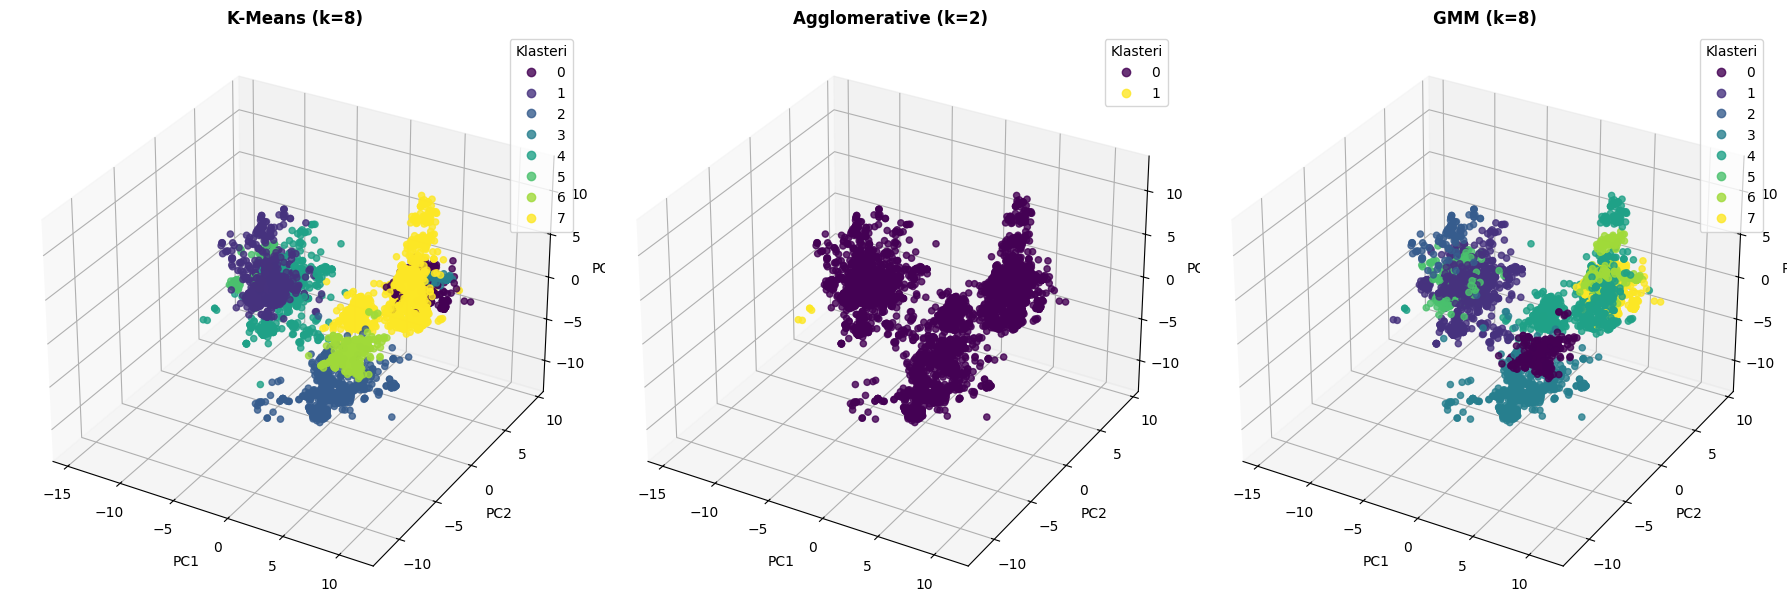

In [45]:
res_all = run_hantavirus_clustering_pipeline(all_4_mers, n_components=0.8, plot=True)

In [46]:
agg_single_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['agglomerative'],
    data=all_4_mers,
    segments=res_all['segments'],
    species=res_all['species'],
    model_name="Agglomerative (Single Linkage)"
)


========================= ANALIZA ZA: AGGLOMERATIVE (SINGLE LINKAGE) =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,881,1483,2810
1,0,0,5



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,438,1667,2823,246
1,0,0,5,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=5174, pretežno S segment) -> Orthohantavirus puumalaense: 2823 (54.6%), Orthohantavirus hantanense: 1667 (32.2%), Orthohantavirus dobravaense: 438 (8.5%)
  Klaster 1 (N=5, pretežno S segment) -> Orthohantavirus puumalaense: 5 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> ATGG (Z=0.00), AAAG (Z=0.00), CAGA (Z=0.00)
  Klaster 1 -> TAAT (Z=7.50), ATTA (Z=6.44), TACT (Z=5.86)


### Poređenje rezultata klasterovanja (4-meri svih sekvenci , N = 5179)

* **Uticaj dimenzionalnosti i parcijalnih sekvenci na separaciju i metrike (K-Means i GMM):**
  * Prelaskom na 256 dimenzija i redukcijom na 50 PCA komponenti, K-Means i GMM izdvajaju $k = 8$ klastera.
  * Silueta koeficijent opada u poređenju sa 3-merima (K-Means: **0.2033**, GMM: **0.1834**), dok Davies-Bouldin indeks raste (**1.8283** i **1.8748**), što je očekivana posledica veće dimenzionalnosti i prisustva parcijalnih sekvenci.
    
* **Problem jednostrukog povezivanja (Agglomerative - single linkage):**
  * Iako aglomerativni model ima najbolje silueta koeficijent ponovo je u pitanju posledica efekta lančanja, pa je odbačen ovaj rezultat i ponovo je pokrenut algoritam sa wardovim povezivanjem.

In [47]:
best_params, best_metrics, agg_labels = optimize_and_print_agglomerative(
    res_all['X_pca'], 
    cluster_range=range(2, 9),
    linkages=['ward']
)

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 8
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silhouette Score: 0.1758
Davies-Bouldin Index: 1.9611


In [48]:
res_all['labels']['agglomerative'] = agg_labels
res_all['params']['agglomerative'] = best_params
res_all['metrics']['agglomerative'] = best_metrics

In [49]:
kmeans_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['kmeans'], 
    data= all_4_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="K-Means"
)

agg_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['agglomerative'], 
    data= all_4_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="Agglomerative"
)

gmm_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['gmm'], 
    data= all_4_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="GMM"
)


========================= ANALIZA ZA: K-MEANS =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,0,0,353
1,2,1273,3
2,0,2,722
3,0,0,149
4,878,8,58
5,0,200,0
6,0,0,280
7,1,0,1250



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,0,0,353,0
1,92,598,479,109
2,28,645,0,51
3,0,0,149,0
4,37,423,398,86
5,0,0,200,0
6,280,0,0,0
7,1,1,1249,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=353, pretežno S segment) -> Orthohantavirus puumalaense: 353 (100.0%)
  Klaster 1 (N=1278, pretežno M segment) -> Orthohantavirus hantanense: 598 (46.8%), Orthohantavirus puumalaense: 479 (37.5%), Orthohantavirus sinnombreense: 109 (8.5%)
  Klaster 2 (N=724, pretežno S segment) -> Orthohantavirus hantanense: 645 (89.1%), Orthohantavirus sinnombreense: 51 (7.0%), Orthohantavirus dobravaense: 28 (3.9%)
  Klaster 3 (N=149, pretežno S segment) -> Orthohantavirus puumalaense: 149 (100.0%)
  Klaster 4 (N=944, pretežno L segment) -> Orthohantavirus hantanense: 423 (44.8%), Orthohantavirus puumalaense: 398 (42.2%), Orthohantavirus sinnombreense: 86 (9.1%)
  Klaster 5 (N=200, pretežno M segment) -> Orthohantavirus puumalaense: 200 (100.0%)
  Klaster 6 (N=280, pretežno S segment) -> Orthohantavirus dobravaense: 280 (100.0%)
  Klaster 7 (N=1251, pretežno S segment) -> Orthohantavirus puumalaense: 1249 (99.8%), Orthohantavirus hantanense: 1 (0

...


--- Dominantne vrste po klasterima ---
  Klaster 0 (N=486, pretežno S segment) -> Orthohantavirus puumalaense: 486 (100.0%)
  Klaster 1 (N=352, pretežno M segment) -> Orthohantavirus puumalaense: 352 (100.0%)
  Klaster 2 (N=881, pretežno L segment) -> Orthohantavirus hantanense: 420 (47.7%), Orthohantavirus puumalaense: 381 (43.2%), Orthohantavirus sinnombreense: 42 (4.8%)
  Klaster 3 (N=1302, pretežno S segment) -> Orthohantavirus puumalaense: 1278 (98.2%), Orthohantavirus hantanense: 22 (1.7%), Orthohantavirus sinnombreense: 2 (0.2%)
  Klaster 4 (N=311, pretežno S segment) -> Orthohantavirus dobravaense: 308 (99.0%), Orthohantavirus hantanense: 3 (1.0%)
  Klaster 5 (N=1021, pretežno M segment) -> Orthohantavirus hantanense: 487 (47.7%), Orthohantavirus puumalaense: 331 (32.4%), Orthohantavirus sinnombreense: 111 (10.9%)
  Klaster 6 (N=109, pretežno M segment) -> Orthohantavirus hantanense: 109 (100.0%)
  Klaster 7 (N=717, pretežno S segment) -> Orthohantavirus hantanense: 626 (87.3%

Segment,L,M,S
Cluster,,,
0,0,0,289
1,879,1067,48
2,0,109,0
3,1,4,715
4,1,0,999
5,0,303,0
6,0,0,318
7,0,0,446



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,289,0,0,0
1,129,906,764,195
2,0,109,0,0
3,20,650,0,50
4,0,1,998,1
5,0,1,302,0
6,0,0,318,0
7,0,0,446,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=289, pretežno S segment) -> Orthohantavirus dobravaense: 289 (100.0%)
  Klaster 1 (N=1994, pretežno M segment) -> Orthohantavirus hantanense: 906 (45.4%), Orthohantavirus puumalaense: 764 (38.3%), Orthohantavirus sinnombreense: 195 (9.8%)
  Klaster 2 (N=109, pretežno M segment) -> Orthohantavirus hantanense: 109 (100.0%)
  Klaster 3 (N=720, pretežno S segment) -> Orthohantavirus hantanense: 650 (90.3%), Orthohantavirus sinnombreense: 50 (6.9%), Orthohantavirus dobravaense: 20 (2.8%)
  Klaster 4 (N=1000, pretežno S segment) -> Orthohantavirus puumalaense: 998 (99.8%), Orthohantavirus hantanense: 1 (0.1%), Orthohantavirus sinnombreense: 1 (0.1%)
  Klaster 5 (N=303, pretežno M segment) -> Orthohantavirus puumalaense: 302 (99.7%), Orthohantavirus hantanense: 1 (0.3%)
  Klaster 6 (N=318, pretežno S segment) -> Orthohantavirus puumalaense: 318 (100.0%)
  Klaster 7 (N=446, pretežno S segment) -> Orthohantavirus puumalaense: 446 (100.0%)



### Interpretacija klastera (4-meri svih sekvenci, N = 5179)

Uvođenje parcijalnih sekvenci u analizu 4-mera pokazuje slične zakonitosti uočene kod 3-mera.

Kao reprezentativni model izabran je **K-Means ($k = 8$)**, uz poređenje sa aglomerativnim modelom (Ward) i GMM-om.

* **L segment:** Skoro sve sekvence ostaju u jednom dominantnom klasteru kod sva tri algoritma (K-Means 878/881, aglomerativni 880/881, GMM 879/881). Interesantno je da je samo kod aglomerativnog modela taj klaster gotovo skroz čist (880 L segmenata i samo jedan M segment). Kod K-Means modela (Klaster 4) prisutno je i 8 instanci M segmenta i 58 instanci S segmenta, dok je kod GMM-a taj klaster obuhvatio i veliku većinu M segmenata (1.067) uz 48 S segmenata.
* **M segment:** Kod sva tri modela M segment se odvaja u više klastera, pri čemu je većina instanci (1.017-1.273) smeštena u jedan klaster. Kod K-Means i aglomerativnog modela taj klaster je skoro skroz sačinjen od M segmenata (K-Means Klaster 1: 1.273 M, 3 L, 2 S; aglomerativni: 1.017 M, 3 L, 1 S), dok kod GMM-a čini deo malopre pomenutog velikog mešovitog klastera sa L segmentima (i 48 S). 
  
* **S segment:** I dalje najbolje odvaja vrste virusa (opisani su reprezentativni K-Means klasteri).
  * *O. dobravaense* formira savršeno čist klaster (Klaster 6, 100%).
  * *O. hantanense*  čini 89.1% instanci mešovitog Klastera 2 kod kog se primećuju prepoznatljivi GC motivi.
  * *O. puumalaense* se usled brojne zastupljenosti deli na tri skoro čista klastera (Klasteri 0, 3 i 7), gde se posebno ističe Klaster 3 sa izrazito visokim Z-skorom motiva `GGCT` ($Z = 3.01$).

### Ključni 4-mer biomarkeri po klasterima (K-Means, N = 5179)

| Klaster | Dominantni segment i vrsta | Ključni 4-meri | Raspon Z-skora |
|---|---|---|---|
| **Klaster 0** | S: *O. puumalaense* (100%) | `AACC`, `ACGC` | 2.10 - 2.29 | 
| **Klaster 1** | M segment, mešovite vrste | `CACA`, `GTGT` | 0.99 - 1.01 |
| **Klaster 2** | S: *O. hantanense* (89.1%) | `GGCA`, `GAGC` | 1.31 - 1.60 | 
| **Klaster 3** | S: *O. puumalaense* (100%) | `GGCT`, `CTGA` | 2.98 - 3.01 | 
| **Klaster 4** | L segment, mešovite vrste | `TAGA`, `TTAG` | 1.19 - 1.32 | 
| **Klaster 5** | M: *O. puumalaense* (100%) | `AATG`, `TGTC` | 2.50 - 3.12 | 
| **Klaster 6** | S: *O. dobravaense* (100%) | `CGTG`, `AAGG` | 2.28 - 2.66 | 
| **Klaster 7** | S: *O. puumalaense* (99.8%) | `CCCG`, `CCAG` | 0.87 - 0.95 |

# Čuvanje rezultata

In [51]:
row_complete = extract_kmer_summary(res_complete, k_val=4, dataset_type='Complete')

In [52]:
row_all = extract_kmer_summary(res_all, k_val=4, dataset_type='All')

In [53]:
summary_4_mers = pd.DataFrame([row_complete, row_all])

In [54]:
output_path = '../data/sequences_kmers/summary_4_mers.csv'
summary_4_mers.to_csv(output_path, index=False)

In [55]:
summary_4_mers

,k,Dataset,Features,PCA_comps,KMeans_k,KMeans_Sil,KMeans_DB,GMM_k,GMM_Sil,GMM_DB,Agg_k,Agg_linkage,Agg_Sil,Agg_DB
0,4,Complete,256,23,8,0.4171,1.0587,8,0.4171,1.0587,8,ward,0.4362,1.1588
1,4,All,256,50,8,0.2033,1.8283,8,0.1834,1.8748,8,ward,0.1758,1.9611
